# MalarIA: Clasificación de células sanguíneas con EfficientNet-B0

Este notebook implementa un modelo de Deep Learning para clasificar imágenes microscópicas de células sanguíneas en dos categorías:

- **Parasitized:** células parasitadas por malaria.
- **Uninfected:** células no infectadas.

Se utiliza el dataset **Cell Images for Detecting Malaria** disponible en Kaggle y una arquitectura **EfficientNet-B0 preentrenada en ImageNet**.

El flujo del proyecto comprende:

1. Configuración del entorno y GPU.
2. Descarga y preparación del dataset.
3. Exploración visual de las imágenes.
4. Preprocesamiento y Data Augmentation.
5. División en entrenamiento, validación y prueba.
6. Construcción de DataLoaders.
7. Transfer Learning con EfficientNet-B0.
8. Fine-Tuning de las capas superiores.
9. Evaluación del modelo.
10. Análisis de la matriz de confusión.
11. Visualización de predicciones.
12. Interpretabilidad mediante Grad-CAM.

## 1. Configuración del entorno

En esta sección se instalan e importan las librerías necesarias para desarrollar el proyecto.

El entrenamiento se realiza utilizando **PyTorch** y una GPU mediante **CUDA**. Se configura también una semilla aleatoria para mejorar la reproducibilidad del experimento.

El programa verifica que una GPU esté disponible antes de continuar, evitando ejecutar accidentalmente las 50 épocas utilizando únicamente CPU.

In [ ]:
# Instalación de KaggleHub
!pip install -q kagglehub

# Imports
import os
import time
import random
import shutil

from PIL import Image

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader, Subset

from torchvision import datasets, transforms, models

import kagglehub


# Semilla para reproducibilidad
SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# Optimizaciones CUDA
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")


# Verificación de GPU
if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA no está disponible.\n"
        "En Google Colab selecciona:\n"
        "Entorno de ejecución > Cambiar tipo de entorno de ejecución > T4 GPU"
    )


device = torch.device("cuda")

gpu_name = torch.cuda.get_device_name(0)

gpu_memory = (
    torch.cuda.get_device_properties(0).total_memory
    / 1024**3
)


print("=== CONFIGURACIÓN DEL ENTORNO ===")
print(f"PyTorch: {torch.__version__}")
print(f"Dispositivo: {device}")
print(f"GPU: {gpu_name}")
print(f"Memoria GPU: {gpu_memory:.2f} GB")

=== CONFIGURACIÓN DEL ENTORNO ===
PyTorch: 2.11.0+cu128
Dispositivo: cuda
GPU: Tesla T4
Memoria GPU: 14.56 GB


## 2. Definición de hiperparámetros

En esta sección se establecen los principales parámetros utilizados durante el entrenamiento.

Las imágenes son redimensionadas a **128 × 128 píxeles** para mantener un equilibrio entre información visual y costo computacional.

El tamaño del batch se determina automáticamente en función de la memoria disponible en la GPU.

El entrenamiento consta de **50 épocas**, divididas en:

- **35 épocas de Feature Extraction**, en las que el extractor de características permanece congelado.
- **15 épocas de Fine-Tuning**, en las que se descongelan los últimos bloques de EfficientNet-B0.

El dataset se divide en 70 % de entrenamiento, 15 % de validación y 15 % de prueba.

In [ ]:
# Tamaño de las imágenes
IMAGE_SIZE = 128


# Batch dinámico dependiendo de la memoria GPU
if gpu_memory >= 14:
    BATCH_SIZE = 256

elif gpu_memory >= 10:
    BATCH_SIZE = 128

else:
    BATCH_SIZE = 64


# Épocas
FEATURE_EPOCHS = 35
FINETUNE_EPOCHS = 15

TOTAL_EPOCHS = FEATURE_EPOCHS + FINETUNE_EPOCHS


# División del dataset
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15


# Workers para DataLoader
NUM_WORKERS = min(
    4,
    os.cpu_count() or 2
)


# Cronómetro total del notebook
total_start = time.time()


print("=== HIPERPARÁMETROS ===")
print(f"Resolución: {IMAGE_SIZE} x {IMAGE_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Feature Extraction: {FEATURE_EPOCHS} épocas")
print(f"Fine-Tuning: {FINETUNE_EPOCHS} épocas")
print(f"Épocas totales: {TOTAL_EPOCHS}")
print(f"Workers: {NUM_WORKERS}")

=== HIPERPARÁMETROS ===
Resolución: 128 x 128
Batch size: 256
Feature Extraction: 35 épocas
Fine-Tuning: 15 épocas
Épocas totales: 50
Workers: 2


## 3. Descarga del dataset

Se utiliza el dataset **Cell Images for Detecting Malaria**, disponible públicamente en Kaggle.

El conjunto contiene imágenes microscópicas reales de células sanguíneas agrupadas en dos categorías:

- `Parasitized`
- `Uninfected`

El dataset se descarga automáticamente mediante `kagglehub`, por lo que no es necesario almacenar las imágenes directamente dentro del repositorio de GitHub.

In [ ]:
print("=== DESCARGA DEL DATASET ===")


dataset_path = kagglehub.dataset_download(
    "iarunava/cell-images-for-detecting-malaria",
    output_dir="/content/malaria_dataset"
)


print("\nDataset descargado correctamente.")
print("Ruta:")
print(dataset_path)

=== DESCARGA DEL DATASET ===
Using Colab cache for faster access to the 'cell-images-for-detecting-malaria' dataset.

Dataset descargado correctamente.
Ruta:
/kaggle/input/cell-images-for-detecting-malaria


## 4. Preparación de la estructura del dataset

Después de descargar los archivos se localizan automáticamente las carpetas correspondientes a las dos clases.

Debido a que el dataset puede contener carpetas anidadas, se busca el directorio que contenga simultáneamente las carpetas `Parasitized` y `Uninfected`.

Posteriormente se crea una estructura limpia para asegurar que `ImageFolder` de PyTorch reconozca únicamente las dos clases necesarias.

In [ ]:
candidate_roots = []


for current_root, directories, files in os.walk(dataset_path):

    dirs = set(directories)

    if (
        "Parasitized" in dirs
        and "Uninfected" in dirs
    ):
        candidate_roots.append(current_root)


if not candidate_roots:
    raise RuntimeError(
        "No se encontraron las carpetas "
        "'Parasitized' y 'Uninfected'."
    )


# Escoger la ruta menos anidada
source_root = min(
    candidate_roots,
    key=lambda x: len(x.split(os.sep))
)


parasitized_path = os.path.join(
    source_root,
    "Parasitized"
)

uninfected_path = os.path.join(
    source_root,
    "Uninfected"
)


print("Carpeta Parasitized:")
print(parasitized_path)

print("\nCarpeta Uninfected:")
print(uninfected_path)


# Crear una carpeta limpia
clean_root = "/content/malaria_binary"


if os.path.exists(clean_root):
    shutil.rmtree(clean_root)


os.makedirs(
    clean_root,
    exist_ok=True
)


# Crear enlaces simbólicos hacia las imágenes originales
os.symlink(
    parasitized_path,
    os.path.join(
        clean_root,
        "Parasitized"
    )
)


os.symlink(
    uninfected_path,
    os.path.join(
        clean_root,
        "Uninfected"
    )
)


print("\nDataset preparado en:")
print(clean_root)

Carpeta Parasitized:
/kaggle/input/cell-images-for-detecting-malaria/cell_images/Parasitized

Carpeta Uninfected:
/kaggle/input/cell-images-for-detecting-malaria/cell_images/Uninfected

Dataset preparado en:
/content/malaria_binary


## 5. Exploración inicial del dataset

Antes de entrenar el modelo se realiza una exploración básica para verificar que los datos hayan sido cargados correctamente.

Se muestran:

- las clases detectadas;
- el número total de imágenes;
- la cantidad de imágenes de cada categoría.

Esta etapa permite comprobar la estructura del problema de clasificación antes de continuar con el entrenamiento.

In [ ]:
raw_dataset = datasets.ImageFolder(
    clean_root
)


print("=== INFORMACIÓN DEL DATASET ===")

print("\nClases detectadas:")
print(raw_dataset.classes)

print("\nMapeo clase → índice:")
print(raw_dataset.class_to_idx)

print("\nTotal de imágenes:")
print(len(raw_dataset))


# Contar imágenes por clase
class_counts = [
    0 for _ in raw_dataset.classes
]


for image_path, label in raw_dataset.samples:
    class_counts[label] += 1


print("\nDistribución por clase:")

for index, class_name in enumerate(
    raw_dataset.classes
):

    print(
        f"{class_name}: "
        f"{class_counts[index]} imágenes"
    )

=== INFORMACIÓN DEL DATASET ===

Clases detectadas:
['Parasitized', 'Uninfected']

Mapeo clase → índice:
{'Parasitized': 0, 'Uninfected': 1}

Total de imágenes:
27558

Distribución por clase:
Parasitized: 13779 imágenes
Uninfected: 13779 imágenes


## 6. Visualización de imágenes del dataset

Se seleccionan ejemplos aleatorios de ambas clases para inspeccionar visualmente el contenido del conjunto de datos.

Las imágenes mostradas corresponden directamente al dataset original y no son imágenes sintéticas.

La primera fila presenta células `Parasitized` y la segunda fila células `Uninfected`.

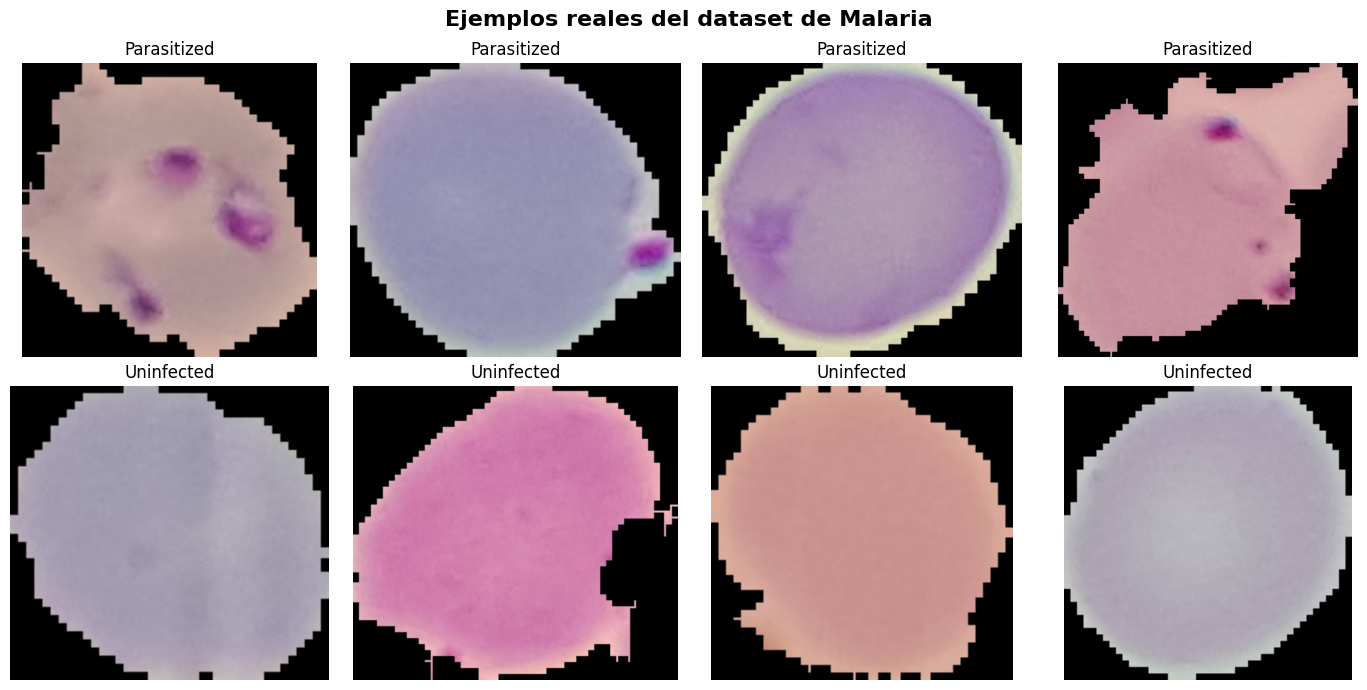

In [ ]:
parasitized_label = (
    raw_dataset.class_to_idx[
        "Parasitized"
    ]
)

uninfected_label = (
    raw_dataset.class_to_idx[
        "Uninfected"
    ]
)


parasitized_images = []
uninfected_images = []


for image_path, label in raw_dataset.samples:

    if label == parasitized_label:
        parasitized_images.append(
            image_path
        )

    elif label == uninfected_label:
        uninfected_images.append(
            image_path
        )


# Selección reproducible
generator = torch.Generator()
generator.manual_seed(SEED)


p_indices = torch.randperm(
    len(parasitized_images),
    generator=generator
)[:4]


u_indices = torch.randperm(
    len(uninfected_images),
    generator=generator
)[:4]


fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 7)
)


fig.suptitle(
    "Ejemplos reales del dataset de Malaria",
    fontsize=16,
    fontweight="bold"
)


# Parasitized
for i, idx in enumerate(
    p_indices
):

    image = Image.open(
        parasitized_images[
            idx.item()
        ]
    ).convert("RGB")


    axes[0, i].imshow(image)
    axes[0, i].set_title("Parasitized")
    axes[0, i].axis("off")


# Uninfected
for i, idx in enumerate(
    u_indices
):

    image = Image.open(
        uninfected_images[
            idx.item()
        ]
    ).convert("RGB")


    axes[1, i].imshow(image)
    axes[1, i].set_title("Uninfected")
    axes[1, i].axis("off")


plt.tight_layout()
plt.show()

## 7. Preprocesamiento y Data Augmentation

Las imágenes del dataset presentan dimensiones variables, por lo que todas son redimensionadas a **128 × 128 píxeles**.

Durante el entrenamiento se aplican técnicas de Data Augmentation:

- volteo horizontal;
- volteo vertical;
- pequeñas rotaciones aleatorias.

Estas transformaciones se aplican dinámicamente sobre las imágenes reales durante cada época y no generan archivos nuevos ni imágenes sintéticas permanentes.

Finalmente, las imágenes son transformadas a tensores y normalizadas utilizando los valores correspondientes a ImageNet, debido a que EfficientNet-B0 utiliza pesos preentrenados sobre dicho dataset.

Las imágenes de validación y prueba no reciben Data Augmentation.

In [ ]:
# Normalización utilizada por modelos preentrenados en ImageNet
MEAN = [
    0.485,
    0.456,
    0.406
]

STD = [
    0.229,
    0.224,
    0.225
]


# Transformaciones de entrenamiento
train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        MEAN,
        STD
    )
])


# Transformaciones de validación y test
eval_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        MEAN,
        STD
    )
])


print("Transformaciones configuradas correctamente.")

Transformaciones configuradas correctamente.


## 8. División del dataset

El conjunto de imágenes se divide de forma estratificada para conservar la proporción de ambas clases.

La distribución utilizada es:

- **70 %:** entrenamiento.
- **15 %:** validación.
- **15 %:** prueba.

El conjunto de entrenamiento se utiliza para actualizar los parámetros del modelo.

El conjunto de validación permite observar el comportamiento del modelo durante las épocas y seleccionar el mejor estado.

El conjunto de prueba se reserva para realizar la evaluación final.

In [ ]:
train_indices = []
val_indices = []
test_indices = []


generator = torch.Generator()
generator.manual_seed(SEED)


# Realizar split independientemente para cada clase
for class_id in range(
    len(raw_dataset.classes)
):

    indices = [

        index

        for index, (_, label)
        in enumerate(
            raw_dataset.samples
        )

        if label == class_id
    ]


    indices = torch.tensor(
        indices,
        dtype=torch.long
    )


    permutation = torch.randperm(
        len(indices),
        generator=generator
    )


    indices = indices[
        permutation
    ]


    n = len(indices)

    n_train = int(
        TRAIN_RATIO * n
    )

    n_val = int(
        VAL_RATIO * n
    )


    train_indices.extend(
        indices[
            :n_train
        ].tolist()
    )


    val_indices.extend(
        indices[
            n_train:
            n_train + n_val
        ].tolist()
    )


    test_indices.extend(
        indices[
            n_train + n_val:
        ].tolist()
    )


# Mezclar cada split de forma reproducible
train_indices = torch.tensor(
    train_indices
)

val_indices = torch.tensor(
    val_indices
)

test_indices = torch.tensor(
    test_indices
)


train_indices = train_indices[
    torch.randperm(
        len(train_indices),
        generator=generator
    )
].tolist()


val_indices = val_indices[
    torch.randperm(
        len(val_indices),
        generator=generator
    )
].tolist()


test_indices = test_indices[
    torch.randperm(
        len(test_indices),
        generator=generator
    )
].tolist()


print("=== DIVISIÓN DEL DATASET ===")

print(
    f"Train: {len(train_indices)} imágenes"
)

print(
    f"Validation: {len(val_indices)} imágenes"
)

print(
    f"Test: {len(test_indices)} imágenes"
)

print(
    "Total:",
    len(train_indices)
    + len(val_indices)
    + len(test_indices)
)

=== DIVISIÓN DEL DATASET ===
Train: 19290 imágenes
Validation: 4132 imágenes
Test: 4136 imágenes
Total: 27558


## 9. Construcción de datasets y DataLoaders

Se crean versiones independientes del dataset para entrenamiento, validación y prueba.

El conjunto de entrenamiento utiliza Data Augmentation, mientras que validación y prueba únicamente aplican redimensionamiento y normalización.

Los DataLoaders permiten procesar las imágenes mediante batches y facilitan su transferencia hacia la GPU.

También se utilizan `pin_memory` y múltiples workers para mejorar el rendimiento durante la carga de imágenes.

In [ ]:
# Dataset con transformaciones de entrenamiento
train_full = datasets.ImageFolder(
    clean_root,
    transform=train_transform
)


# Dataset de validación
val_full = datasets.ImageFolder(
    clean_root,
    transform=eval_transform
)


# Dataset de prueba
test_full = datasets.ImageFolder(
    clean_root,
    transform=eval_transform
)


# Aplicar índices
train_dataset = Subset(
    train_full,
    train_indices
)


val_dataset = Subset(
    val_full,
    val_indices
)


test_dataset = Subset(
    test_full,
    test_indices
)


print("=== SUBCONJUNTOS ===")

print(
    f"Train: {len(train_dataset)}"
)

print(
    f"Validation: {len(val_dataset)}"
)

print(
    f"Test: {len(test_dataset)}"
)


# DataLoader Train
train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=(
        NUM_WORKERS > 0
    )
)


# DataLoader Validation
val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=(
        NUM_WORKERS > 0
    )
)


# DataLoader Test
test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=(
        NUM_WORKERS > 0
    )
)


print("\n=== BATCHES ===")

print(
    f"Train: {len(train_loader)}"
)

print(
    f"Validation: {len(val_loader)}"
)

print(
    f"Test: {len(test_loader)}"
)

=== SUBCONJUNTOS ===
Train: 19290
Validation: 4132
Test: 4136

=== BATCHES ===
Train: 76
Validation: 17
Test: 17


## 10. Verificación visual del pipeline de datos

Antes de comenzar el entrenamiento se muestra un batch después de aplicar el preprocesamiento.

Las imágenes se desnormalizan únicamente para su visualización mediante Matplotlib.

Esta etapa permite comprobar que:

- las imágenes se cargan correctamente;
- las etiquetas corresponden a las categorías correctas;
- las transformaciones funcionan;
- las dimensiones de entrada son adecuadas.

Forma del batch de imágenes: torch.Size([256, 3, 128, 128])
Forma del batch de etiquetas: torch.Size([256])


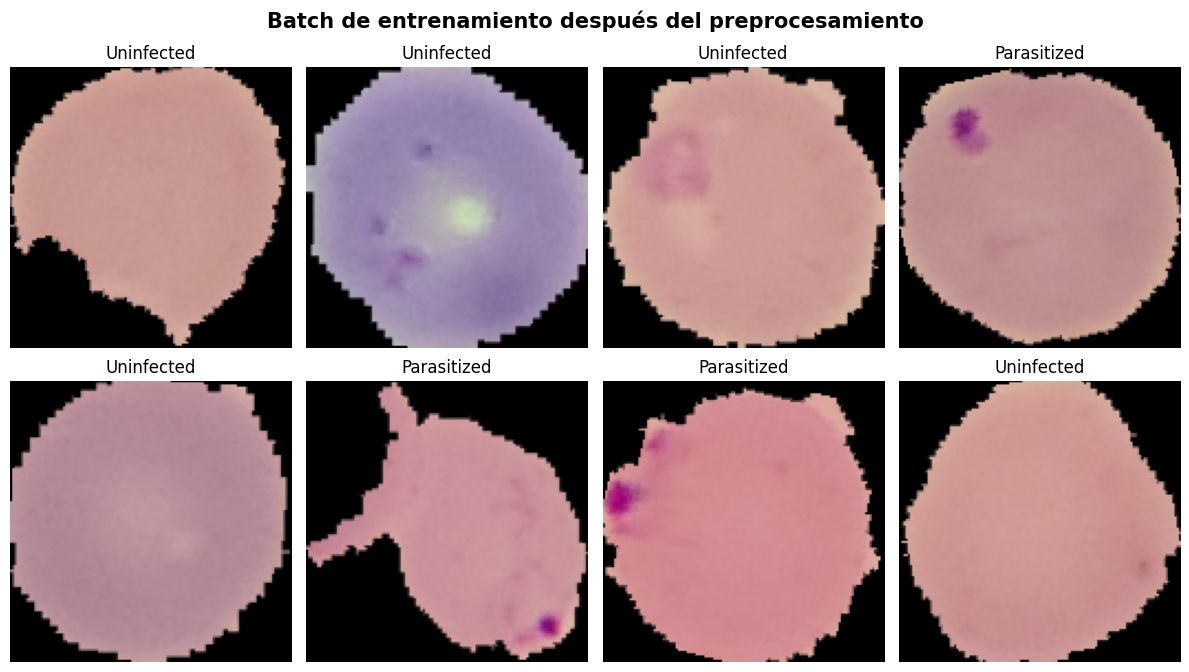

In [ ]:
images, labels = next(
    iter(train_loader)
)


print(
    "Forma del batch de imágenes:",
    images.shape
)

print(
    "Forma del batch de etiquetas:",
    labels.shape
)


# Tensores para revertir la normalización
mean_tensor = torch.tensor(
    MEAN
).view(
    3,
    1,
    1
)


std_tensor = torch.tensor(
    STD
).view(
    3,
    1,
    1
)


fig, axes = plt.subplots(
    2,
    4,
    figsize=(12, 7)
)


fig.suptitle(
    "Batch de entrenamiento después del preprocesamiento",
    fontsize=15,
    fontweight="bold"
)


for i, ax in enumerate(
    axes.flat
):

    image = (
        images[i]
        * std_tensor
        + mean_tensor
    ).clamp(
        0,
        1
    )


    ax.imshow(
        image.permute(
            1,
            2,
            0
        )
    )


    ax.set_title(
        raw_dataset.classes[
            labels[i].item()
        ]
    )


    ax.axis("off")


plt.tight_layout()
plt.show()


del images
del labels

## 11. Construcción del modelo EfficientNet-B0

Se utiliza la arquitectura **EfficientNet-B0** con pesos previamente entrenados sobre ImageNet.

El modelo original puede clasificar 1000 categorías, por lo que su capa final se sustituye por un nuevo clasificador de dos salidas:

- `Parasitized`
- `Uninfected`

Inicialmente se congelan todos los parámetros del extractor de características.

De esta manera, durante la primera fase únicamente se entrena la nueva cabeza de clasificación.

In [ ]:
print("=== EFFICIENTNET-B0 ===")


# Pesos preentrenados
weights = (
    models.EfficientNet_B0_Weights.DEFAULT
)


# Crear EfficientNet-B0
model = models.efficientnet_b0(
    weights=weights
)


# Congelar todos los parámetros
for parameter in model.parameters():
    parameter.requires_grad = False


# Número de entradas de la capa final
in_features = (
    model.classifier[1].in_features
)


# Reemplazar la última capa por una de 2 clases
model.classifier[1] = nn.Linear(
    in_features,
    2
)


# La cabeza de clasificación será entrenable
for parameter in model.classifier.parameters():
    parameter.requires_grad = True


# Enviar modelo a GPU
model = model.to(device)


print("\nClasificador:")
print(model.classifier)


trainable_parameters = sum(

    parameter.numel()

    for parameter in model.parameters()

    if parameter.requires_grad
)


print(
    "\nParámetros entrenables inicialmente:"
)

print(
    f"{trainable_parameters:,}"
)

=== EFFICIENTNET-B0 ===

Clasificador:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)

Parámetros entrenables inicialmente:
2,562


## 12. Configuración del entrenamiento

Para entrenar el modelo se utiliza `CrossEntropyLoss`, adecuada para problemas de clasificación.

Como optimizador se utiliza **AdamW**.

Durante la primera etapa el Learning Rate es `1e-3`.

También se utiliza **Automatic Mixed Precision**, que permite realizar determinadas operaciones en precisión de 16 bits para mejorar el aprovechamiento de la GPU y reducir el consumo de memoria.

In [ ]:
# Función de pérdida
criterion = nn.CrossEntropyLoss()


# Optimizador inicial
optimizer = optim.AdamW(

    model.classifier.parameters(),

    lr=1e-3,

    weight_decay=1e-4
)


# Mixed Precision
scaler = torch.amp.GradScaler(
    "cuda"
)


# Historial
train_loss_history = []
val_loss_history = []

train_acc_history = []
val_acc_history = []


# Mejor resultado de validación
best_val_acc = 0.0


# Ruta del mejor modelo
best_model_path = (
    "/content/"
    "best_malaria_efficientnet_b0.pt"
)


print("Configuración de entrenamiento completada.")

Configuración de entrenamiento completada.


## 13. Entrenamiento del modelo

El entrenamiento se desarrolla en dos etapas.

### Fase 1: Feature Extraction

Durante las primeras **35 épocas** se mantienen congeladas las características aprendidas previamente por EfficientNet-B0.

En esta etapa únicamente se ajusta el clasificador final al nuevo problema.

### Fase 2: Fine-Tuning

A partir de la época 36 se descongelan los últimos bloques de EfficientNet-B0.

Esto permite adaptar parte del extractor de características específicamente a las imágenes de células sanguíneas.

Durante esta segunda etapa se reduce el Learning Rate a `1e-4`.

En cada época se calculan:

- Training Loss.
- Training Accuracy.
- Validation Loss.
- Validation Accuracy.

El modelo con mejor Accuracy de validación se almacena automáticamente.

In [ ]:
print("=== ENTRENAMIENTO ===")


training_start = time.time()


for epoch in range(
    TOTAL_EPOCHS
):

    epoch_start = time.time()


    # INICIAR FINE-TUNING

    if epoch == FEATURE_EPOCHS:

        print(
            "\n======================================="
        )

        print(
            "INICIO DEL FINE-TUNING"
        )

        print(
            "======================================="
        )


        # Volver a congelar todo
        for parameter in model.parameters():
            parameter.requires_grad = False


        # Descongelar los últimos dos bloques
        for parameter in model.features[-2:].parameters():
            parameter.requires_grad = True


        # Mantener clasificador entrenable
        for parameter in model.classifier.parameters():
            parameter.requires_grad = True


        # Nuevo optimizador con menor learning rate
        optimizer = optim.AdamW(

            filter(
                lambda parameter:
                parameter.requires_grad,

                model.parameters()
            ),

            lr=1e-4,

            weight_decay=1e-4
        )


        trainable_parameters = sum(

            parameter.numel()

            for parameter in model.parameters()

            if parameter.requires_grad
        )


        print(
            "Parámetros entrenables durante Fine-Tuning:"
        )

        print(
            f"{trainable_parameters:,}"
        )

    # ENTRENAMIENTO

    model.train()


    # Mantener BatchNorm estable
    for module in model.modules():

        if isinstance(
            module,
            nn.BatchNorm2d
        ):
            module.eval()


    running_loss = 0.0
    correct = 0
    total = 0


    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        # Mixed Precision
        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model(
                images
            )

            loss = criterion(
                outputs,
                labels
            )


        # Backpropagation
        scaler.scale(
            loss
        ).backward()


        scaler.step(
            optimizer
        )


        scaler.update()


        batch_size_current = labels.size(0)


        running_loss += (
            loss.item()
            * batch_size_current
        )


        predictions = outputs.argmax(
            dim=1
        )


        correct += (
            predictions
            .eq(labels)
            .sum()
            .item()
        )


        total += (
            batch_size_current
        )


    # Resultados de entrenamiento
    train_loss = (
        running_loss
        / total
    )


    train_acc = (
        correct
        / total
    )

    # VALIDACIÓN

    model.eval()


    val_running_loss = 0.0
    val_correct = 0
    val_total = 0


    with torch.inference_mode():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )


            with torch.amp.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = model(
                    images
                )

                loss = criterion(
                    outputs,
                    labels
                )


            batch_size_current = (
                labels.size(0)
            )


            val_running_loss += (
                loss.item()
                * batch_size_current
            )


            predictions = outputs.argmax(
                dim=1
            )


            val_correct += (
                predictions
                .eq(labels)
                .sum()
                .item()
            )


            val_total += (
                batch_size_current
            )


    # Resultados de validación
    val_loss = (
        val_running_loss
        / val_total
    )


    val_acc = (
        val_correct
        / val_total
    )


    # GUARDAR HISTORIAL

    train_loss_history.append(
        train_loss
    )

    val_loss_history.append(
        val_loss
    )

    train_acc_history.append(
        train_acc
    )

    val_acc_history.append(
        val_acc
    )


    # GUARDAR EL MEJOR MODELO

    if val_acc > best_val_acc:

        best_val_acc = (
            val_acc
        )

        torch.save(
            model.state_dict(),
            best_model_path
        )

    # MOSTRAR RESULTADOS DE LA ÉPOCA

    epoch_time = (
        time.time()
        - epoch_start
    ) / 60


    phase = (

        "Feature Extraction"

        if epoch < FEATURE_EPOCHS

        else "Fine-Tuning"
    )


    print(

        f"Epoch "
        f"{epoch + 1:02d}/"
        f"{TOTAL_EPOCHS} | "

        f"{phase:18s} | "

        f"Train Loss: "
        f"{train_loss:.4f} | "

        f"Train Acc: "
        f"{train_acc * 100:.2f}% | "

        f"Val Loss: "
        f"{val_loss:.4f} | "

        f"Val Acc: "
        f"{val_acc * 100:.2f}% | "

        f"Tiempo: "
        f"{epoch_time:.2f} min"
    )


# Tiempo total de entrenamiento
training_time = (
    time.time()
    - training_start
) / 60


print(
    "\n=== ENTRENAMIENTO COMPLETADO ==="
)

print(
    f"Tiempo de entrenamiento: "
    f"{training_time:.2f} minutos"
)

print(
    f"Mejor Validation Accuracy: "
    f"{best_val_acc * 100:.2f}%"
)

=== ENTRENAMIENTO ===
Epoch 01/50 | Feature Extraction | Train Loss: 0.2805 | Train Acc: 89.03% | Val Loss: 0.1911 | Val Acc: 93.44% | Tiempo: 0.75 min
Epoch 02/50 | Feature Extraction | Train Loss: 0.2027 | Train Acc: 92.70% | Val Loss: 0.1749 | Val Acc: 94.19% | Tiempo: 0.72 min
Epoch 03/50 | Feature Extraction | Train Loss: 0.1873 | Train Acc: 93.20% | Val Loss: 0.1657 | Val Acc: 94.48% | Tiempo: 0.71 min
Epoch 04/50 | Feature Extraction | Train Loss: 0.1824 | Train Acc: 93.27% | Val Loss: 0.1651 | Val Acc: 94.19% | Tiempo: 0.73 min
Epoch 05/50 | Feature Extraction | Train Loss: 0.1782 | Train Acc: 93.57% | Val Loss: 0.1593 | Val Acc: 94.24% | Tiempo: 0.71 min
Epoch 06/50 | Feature Extraction | Train Loss: 0.1768 | Train Acc: 93.80% | Val Loss: 0.1553 | Val Acc: 94.60% | Tiempo: 0.71 min
Epoch 07/50 | Feature Extraction | Train Loss: 0.1725 | Train Acc: 93.84% | Val Loss: 0.1543 | Val Acc: 94.77% | Tiempo: 0.77 min
Epoch 08/50 | Feature Extraction | Train Loss: 0.1748 | Train Acc: 9

## 14. Curvas de aprendizaje

Después del entrenamiento se representan gráficamente las métricas obtenidas durante las 50 épocas.

Se muestran:

- Training Loss.
- Validation Loss.
- Training Accuracy.
- Validation Accuracy.

La línea vertical indica el momento en que comienza el Fine-Tuning.

Estas curvas permiten observar la convergencia del modelo, evaluar el efecto del Fine-Tuning y detectar posibles señales de overfitting.

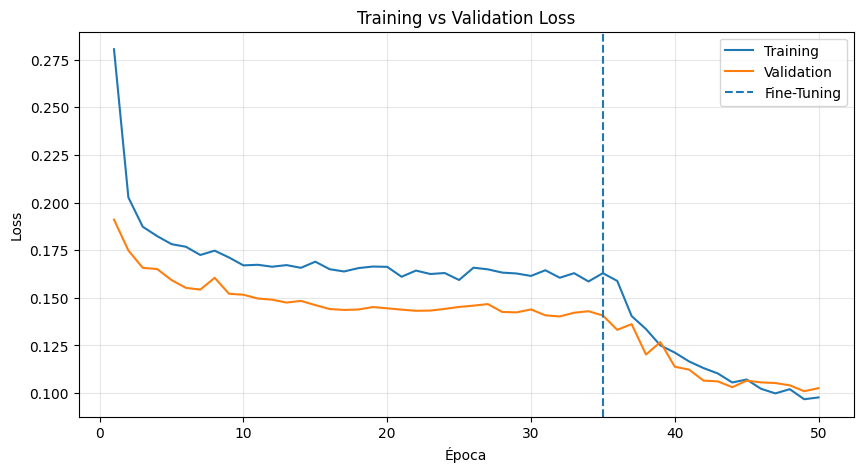

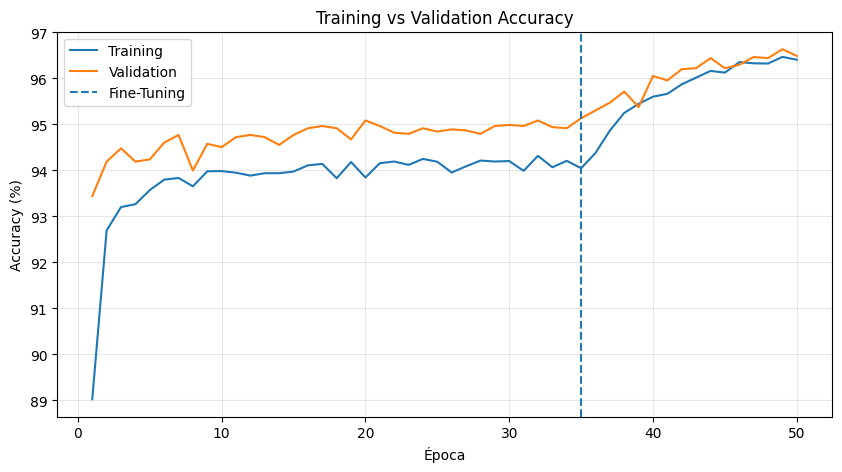

In [ ]:
epochs = list(
    range(
        1,
        TOTAL_EPOCHS + 1
    )
)

# LOSS

plt.figure(
    figsize=(10, 5)
)


plt.plot(
    epochs,
    train_loss_history,
    label="Training"
)


plt.plot(
    epochs,
    val_loss_history,
    label="Validation"
)


plt.axvline(
    FEATURE_EPOCHS,
    linestyle="--",
    label="Fine-Tuning"
)


plt.xlabel("Época")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ACCURACY

plt.figure(
    figsize=(10, 5)
)


plt.plot(
    epochs,

    [
        accuracy * 100
        for accuracy
        in train_acc_history
    ],

    label="Training"
)


plt.plot(
    epochs,

    [
        accuracy * 100
        for accuracy
        in val_acc_history
    ],

    label="Validation"
)


plt.axvline(
    FEATURE_EPOCHS,
    linestyle="--",
    label="Fine-Tuning"
)


plt.xlabel("Época")
plt.ylabel("Accuracy (%)")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 15. Selección del mejor modelo

Durante el entrenamiento se almacenan los pesos correspondientes al modelo que obtiene la mayor Accuracy de validación.

Una vez completadas las 50 épocas, se vuelven a cargar estos pesos antes de realizar la evaluación sobre el conjunto de prueba.

De esta forma se utiliza el mejor modelo observado durante todo el entrenamiento y no necesariamente el correspondiente a la época 50.

In [ ]:
model.load_state_dict(

    torch.load(

        best_model_path,

        map_location=device,

        weights_only=True
    )
)


model.eval()


print(
    "Mejor modelo cargado correctamente."
)

print(
    f"Best Validation Accuracy: "
    f"{best_val_acc * 100:.2f}%"
)

Mejor modelo cargado correctamente.
Best Validation Accuracy: 96.64%


## 16. Evaluación sobre el conjunto de prueba

El mejor modelo se evalúa utilizando el conjunto de prueba, compuesto por imágenes que no fueron utilizadas para actualizar los parámetros durante el entrenamiento.

Se calculan:

- Accuracy.
- Precision.
- Recall.
- F1-score.

Para las métricas binarias se considera `Parasitized` como la clase positiva.

Esto permite evaluar el rendimiento final del modelo sobre imágenes no utilizadas durante el proceso de entrenamiento.

In [ ]:
print("=== TEST ===")


all_targets = []
all_predictions = []
all_probabilities = []


test_correct = 0
test_total = 0

test_loss_total = 0.0


# Considerar Parasitized como clase positiva
positive_index = (
    raw_dataset.class_to_idx[
        "Parasitized"
    ]
)


with torch.inference_mode():

    for images, labels in test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model(
                images
            )

            loss = criterion(
                outputs,
                labels
            )


        probabilities = torch.softmax(
            outputs.float(),
            dim=1
        )


        predictions = outputs.argmax(
            dim=1
        )


        batch_size_current = (
            labels.size(0)
        )


        test_loss_total += (
            loss.item()
            * batch_size_current
        )


        test_correct += (
            predictions
            .eq(labels)
            .sum()
            .item()
        )


        test_total += (
            batch_size_current
        )


        all_targets.append(
            labels.cpu()
        )


        all_predictions.append(
            predictions.cpu()
        )


        all_probabilities.append(

            probabilities[
                :,
                positive_index
            ].cpu()
        )


# Combinar batches
targets = torch.cat(
    all_targets
)

predictions = torch.cat(
    all_predictions
)

probabilities = torch.cat(
    all_probabilities
)


# Loss final
test_loss = (
    test_loss_total
    / test_total
)


# Accuracy
test_accuracy = (
    test_correct
    / test_total
)


print(
    f"Test Loss: "
    f"{test_loss:.4f}"
)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

=== TEST ===
Test Loss: 0.0918
Test Accuracy: 96.57%


## 17. Matriz de confusión y métricas finales

Se genera una matriz de confusión para analizar detalladamente las predicciones del modelo.

Esta permite identificar:

- verdaderos positivos;
- verdaderos negativos;
- falsos positivos;
- falsos negativos.

A partir de estos valores se calculan Precision, Recall y F1-score considerando las células `Parasitized` como la clase positiva.

La matriz se visualiza utilizando Matplotlib.

Matriz de confusión:
tensor([[1986,   82],
        [  60, 2008]])

=== MÉTRICAS ===
Accuracy: 96.57%
Precision: 97.07%
Recall: 96.03%
F1-score: 96.55%


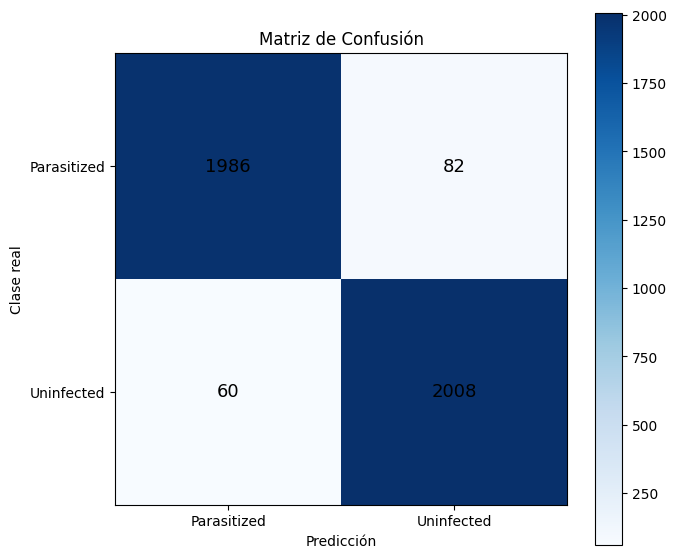

In [ ]:
num_classes = len(
    raw_dataset.classes
)


# Combinar clase real y predicha
pairs = (
    targets
    * num_classes
    + predictions
)


# Crear matriz de confusión
confusion = torch.bincount(

    pairs,

    minlength=(
        num_classes
        * num_classes
    )

).reshape(
    num_classes,
    num_classes
)


print("Matriz de confusión:")

print(confusion)


# MÉTRICAS

positive = positive_index


TP = confusion[
    positive,
    positive
].item()


FN = (
    confusion[
        positive,
        :
    ].sum().item()
    - TP
)


FP = (
    confusion[
        :,
        positive
    ].sum().item()
    - TP
)


TN = (
    confusion.sum().item()
    - TP
    - FN
    - FP
)


precision = (
    TP
    / (
        TP
        + FP
        + 1e-8
    )
)


recall = (
    TP
    / (
        TP
        + FN
        + 1e-8
    )
)


f1 = (
    2
    * precision
    * recall
    / (
        precision
        + recall
        + 1e-8
    )
)


print("\n=== MÉTRICAS ===")

print(
    f"Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Precision: "
    f"{precision * 100:.2f}%"
)

print(
    f"Recall: "
    f"{recall * 100:.2f}%"
)

print(
    f"F1-score: "
    f"{f1 * 100:.2f}%"
)


# VISUALIZACIÓN DE MATRIZ

plt.figure(
    figsize=(7, 6)
)


plt.imshow(
    confusion,
    cmap="Blues"
)


plt.colorbar()


plt.xticks(
    range(num_classes),
    raw_dataset.classes
)


plt.yticks(
    range(num_classes),
    raw_dataset.classes
)


plt.xlabel(
    "Predicción"
)

plt.ylabel(
    "Clase real"
)


plt.title(
    "Matriz de Confusión"
)


for row in range(
    num_classes
):

    for column in range(
        num_classes
    ):

        plt.text(

            column,
            row,

            str(
                confusion[
                    row,
                    column
                ].item()
            ),

            ha="center",
            va="center",
            fontsize=13
        )


plt.tight_layout()
plt.show()

## 18. Visualización de predicciones

Además de las métricas cuantitativas, se muestran predicciones realizadas sobre imágenes reales del conjunto de prueba.

Para cada imagen se presenta:

- la clase real;
- la clase predicha;
- la confianza de la predicción.

Esta visualización permite identificar tanto clasificaciones correctas como errores del modelo.

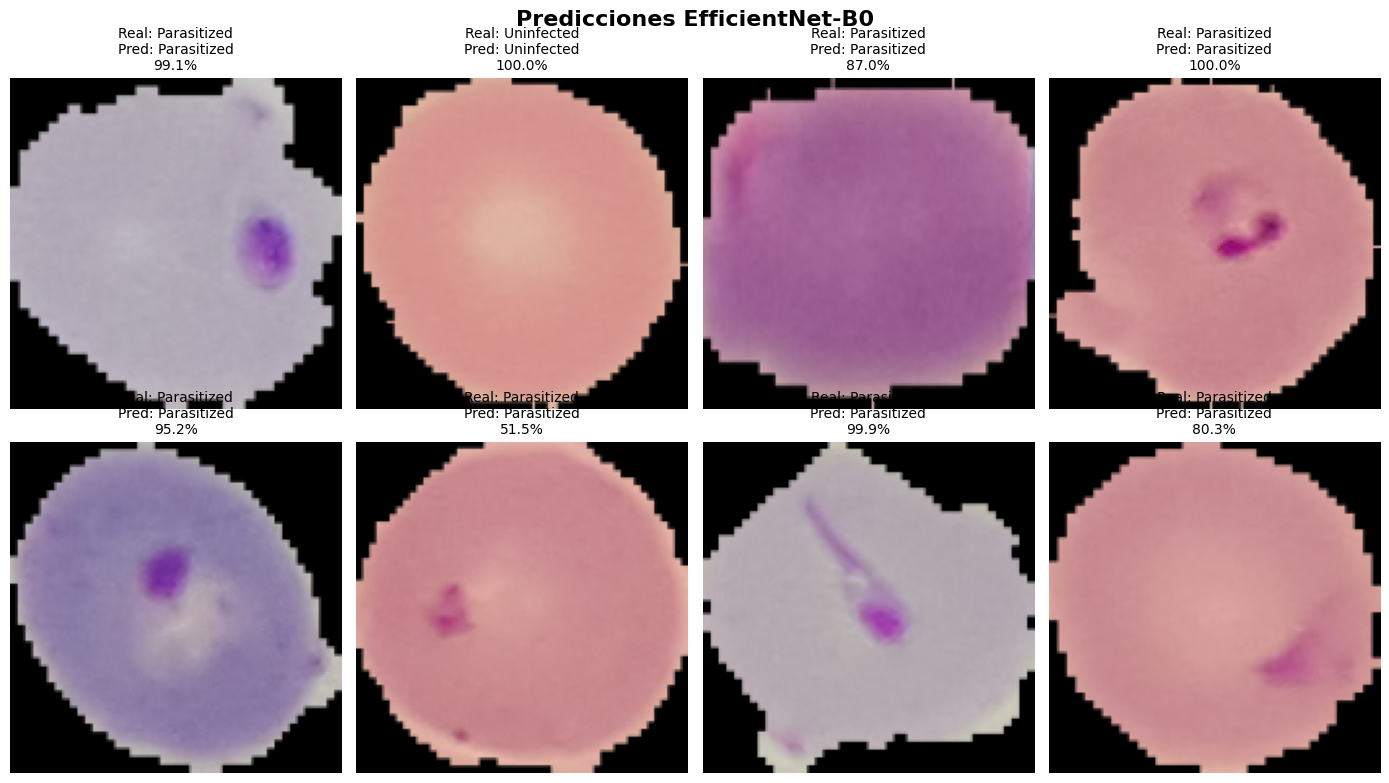

In [ ]:
images, labels = next(
    iter(test_loader)
)


images_gpu = images.to(
    device,
    non_blocking=True
)


with torch.inference_mode():

    with torch.amp.autocast(
        device_type="cuda",
        dtype=torch.float16
    ):

        outputs = model(
            images_gpu
        )


    prediction_probabilities = torch.softmax(
        outputs.float(),
        dim=1
    ).cpu()


    predicted_classes = outputs.argmax(
        dim=1
    ).cpu()


fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 8)
)


fig.suptitle(
    "Predicciones EfficientNet-B0",
    fontsize=16,
    fontweight="bold"
)


for i, ax in enumerate(
    axes.flat
):

    image = (
        images[i]
        * std_tensor
        + mean_tensor
    ).clamp(
        0,
        1
    )


    real_class = (
        raw_dataset.classes[
            labels[i].item()
        ]
    )


    predicted_class = (
        raw_dataset.classes[
            predicted_classes[
                i
            ].item()
        ]
    )


    confidence = (

        prediction_probabilities[
            i,
            predicted_classes[i]
        ].item()

        * 100
    )


    ax.imshow(
        image.permute(
            1,
            2,
            0
        )
    )


    ax.set_title(

        f"Real: {real_class}\n"
        f"Pred: {predicted_class}\n"
        f"{confidence:.1f}%",

        fontsize=10
    )


    ax.axis("off")


plt.tight_layout()
plt.show()


del images_gpu

## 19. Interpretabilidad mediante Grad-CAM

Finalmente se utiliza **Gradient-weighted Class Activation Mapping (Grad-CAM)** para realizar una inspección cualitativa de las regiones que influyen sobre la predicción del modelo.

Grad-CAM utiliza los gradientes y activaciones de las últimas capas convolucionales de EfficientNet-B0 para construir un mapa de calor.

El mapa resultante se superpone sobre la imagen original.

Las zonas con mayor activación representan regiones que contribuyeron en mayor medida a la decisión del modelo.

Grad-CAM no demuestra que el modelo haya identificado directamente una estructura biológica específica; se utiliza únicamente como herramienta de interpretabilidad visual.

=== GRAD-CAM ===


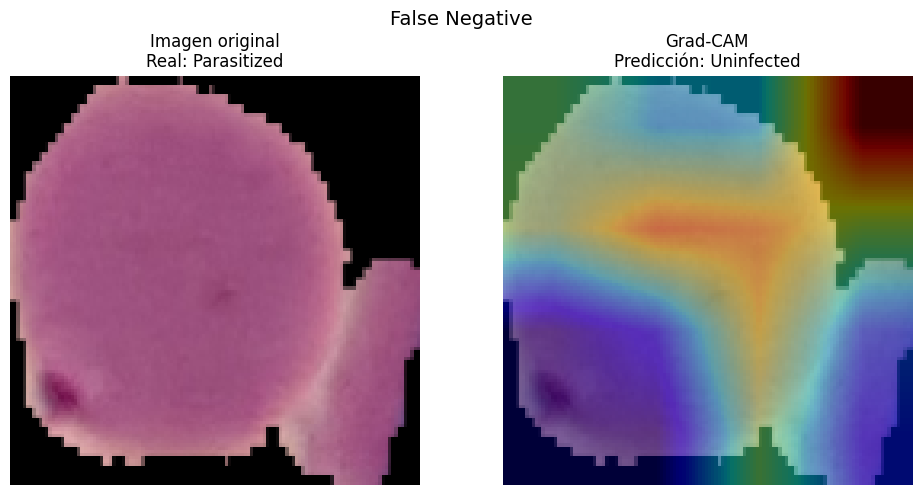

In [ ]:
print("=== GRAD-CAM ===")


# Listas para almacenar activaciones y gradientes
activations = []
gradients = []


# Hook para activaciones
def forward_hook(
    module,
    input,
    output
):

    activations.append(
        output
    )


# Hook para gradientes
def backward_hook(
    module,
    grad_input,
    grad_output
):

    gradients.append(
        grad_output[0]
    )


# Último bloque convolucional de EfficientNet
target_layer = (
    model.features[-1]
)


# Registrar hooks
forward_handle = (
    target_layer.register_forward_hook(
        forward_hook
    )
)


backward_handle = (
    target_layer.register_full_backward_hook(
        backward_hook
    )
)


# BUSCAR UN EJEMPLO INTERESANTE

# Preferiremos un falso negativo si existe:
# Real = Parasitized
# Predicción = Uninfected

negative_index = (
    raw_dataset.class_to_idx[
        "Uninfected"
    ]
)


false_negative_positions = torch.nonzero(

    (
        targets
        == positive_index
    )

    &

    (
        predictions
        == negative_index
    ),

    as_tuple=False

).flatten()


if false_negative_positions.numel() > 0:

    dataset_position = (
        false_negative_positions[
            0
        ].item()
    )

    example_type = (
        "False Negative"
    )

else:

    dataset_position = 0

    example_type = (
        "Ejemplo del conjunto de prueba"
    )


# Obtener imagen
image_tensor, real_label = (
    test_dataset[
        dataset_position
    ]
)


input_tensor = (
    image_tensor
    .unsqueeze(0)
    .to(device)
)


# Limpiar valores anteriores
activations.clear()
gradients.clear()


model.zero_grad(
    set_to_none=True
)


# Forward pass
output = model(
    input_tensor
)


predicted_label = (
    output.argmax(
        dim=1
    ).item()
)


# Score correspondiente a la clase predicha
score = output[
    0,
    predicted_label
]


# Calcular gradientes
score.backward()


# Obtener activaciones
feature_maps = (
    activations[
        0
    ].detach()
)


# Obtener gradientes
feature_gradients = (
    gradients[
        0
    ].detach()
)


# Promedio espacial de gradientes
weights_cam = (
    feature_gradients.mean(
        dim=(2, 3),
        keepdim=True
    )
)


# Combinación ponderada
cam = (
    weights_cam
    * feature_maps
).sum(
    dim=1,
    keepdim=True
)


# Mantener contribuciones positivas
cam = torch.relu(
    cam
)


# Redimensionar al tamaño original procesado
cam = F.interpolate(

    cam,

    size=(
        IMAGE_SIZE,
        IMAGE_SIZE
    ),

    mode="bilinear",

    align_corners=False
)


cam = cam.squeeze()


# Normalizar mapa entre 0 y 1
cam = (
    cam
    - cam.min()
) / (
    cam.max()
    - cam.min()
    + 1e-8
)


cam = cam.cpu()


# Desnormalizar imagen
display_image = (
    image_tensor.cpu()
    * std_tensor
    + mean_tensor
).clamp(
    0,
    1
)


real_name = (
    raw_dataset.classes[
        real_label
    ]
)


predicted_name = (
    raw_dataset.classes[
        predicted_label
    ]
)


# VISUALIZACIÓN

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5)
)


# Imagen original
axes[0].imshow(
    display_image.permute(
        1,
        2,
        0
    )
)


axes[0].set_title(

    f"Imagen original\n"
    f"Real: {real_name}"
)


axes[0].axis(
    "off"
)


# Imagen + Grad-CAM
axes[1].imshow(
    display_image.permute(
        1,
        2,
        0
    )
)


axes[1].imshow(
    cam,
    cmap="jet",
    alpha=0.45
)


axes[1].set_title(

    f"Grad-CAM\n"
    f"Predicción: {predicted_name}"
)


axes[1].axis(
    "off"
)


plt.suptitle(
    example_type,
    fontsize=14
)

plt.tight_layout()
plt.show()


# Eliminar hooks
forward_handle.remove()
backward_handle.remove()

## 20. Resumen de resultados

Al finalizar la ejecución se presenta un resumen con la configuración y los principales resultados obtenidos.

Se muestran:

- arquitectura utilizada;
- GPU empleada;
- cantidad total de imágenes;
- número de imágenes en Train, Validation y Test;
- número total de épocas;
- tamaño del batch;
- resolución de entrada;
- mejor Accuracy de validación;
- Accuracy de prueba;
- Precision;
- Recall;
- F1-score;
- tiempo de entrenamiento;
- tiempo total de ejecución;
- ubicación del archivo correspondiente al mejor modelo.

Este resumen facilita la documentación de los resultados obtenidos en cada ejecución.

In [ ]:
total_time = (
    time.time()
    - total_start
) / 60


print(
    "\n=========================================="
)

print(
    "          RESULTADOS FINALES"
)

print(
    "=========================================="
)


print(
    "Arquitectura: EfficientNet-B0"
)


print(
    f"GPU: {gpu_name}"
)


print(
    f"Imágenes totales: "
    f"{len(raw_dataset)}"
)


print(
    f"Train: "
    f"{len(train_dataset)}"
)


print(
    f"Validation: "
    f"{len(val_dataset)}"
)


print(
    f"Test: "
    f"{len(test_dataset)}"
)


print(
    f"Épocas totales: "
    f"{TOTAL_EPOCHS}"
)


print(
    f"Batch size: "
    f"{BATCH_SIZE}"
)


print(
    f"Resolución: "
    f"{IMAGE_SIZE}x{IMAGE_SIZE}"
)


print(
    f"Mejor Validation Accuracy: "
    f"{best_val_acc * 100:.2f}%"
)


print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)


print(
    f"Precision: "
    f"{precision * 100:.2f}%"
)


print(
    f"Recall: "
    f"{recall * 100:.2f}%"
)


print(
    f"F1-score: "
    f"{f1 * 100:.2f}%"
)


print(
    f"Tiempo de entrenamiento: "
    f"{training_time:.2f} minutos"
)


print(
    f"Tiempo TOTAL: "
    f"{total_time:.2f} minutos"
)


print(
    "\nModelo guardado en:"
)


print(
    best_model_path
)


print(
    "\nProceso finalizado correctamente."
)


          RESULTADOS FINALES
Arquitectura: EfficientNet-B0
GPU: Tesla T4
Imágenes totales: 27558
Train: 19290
Validation: 4132
Test: 4136
Épocas totales: 50
Batch size: 256
Resolución: 128x128
Mejor Validation Accuracy: 96.64%
Test Accuracy: 96.57%
Precision: 97.07%
Recall: 96.03%
F1-score: 96.55%
Tiempo de entrenamiento: 35.28 minutos
Tiempo TOTAL: 35.83 minutos

Modelo guardado en:
/content/best_malaria_efficientnet_b0.pt

Proceso finalizado correctamente.
